In [85]:
import torch
from torch import nn
import torchvision
from torchvision import transforms
print(torch.__version__)
print(torchvision.__version__)

2.10.0+cu128
0.25.0+cu128


In [86]:
print(torch.cuda.is_available())
print(torch.cuda.get_device_name())

True
Tesla T4


In [87]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(device)

cuda


## getting dataset

In [88]:
from torchvision import datasets, transforms


train_data = datasets.FashionMNIST(
    root="../cnn/data",
    train=True,
    download=True,
    transform=transforms.ToTensor(),
    target_transform=None
)

test_data = datasets.FashionMNIST(
    root="../cnn/data",
    train=False,
    download=True,
    transform=transforms.ToTensor(),
    target_transform=None
)

In [89]:
img,label = train_data[0]
print(img.shape)
print(label)

torch.Size([1, 28, 28])
9


In [90]:
class_name = train_data.classes
cls_ind = train_data.class_to_idx
print(class_name)
print(cls_ind)
print(train_data.targets)

['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']
{'T-shirt/top': 0, 'Trouser': 1, 'Pullover': 2, 'Dress': 3, 'Coat': 4, 'Sandal': 5, 'Shirt': 6, 'Sneaker': 7, 'Bag': 8, 'Ankle boot': 9}
tensor([9, 0, 0,  ..., 3, 0, 5])


## visualize the sample data

(np.float64(-0.5), np.float64(27.5), np.float64(27.5), np.float64(-0.5))

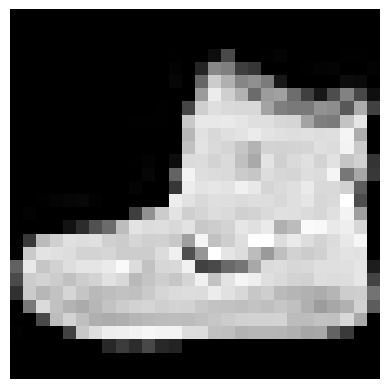

In [91]:
import matplotlib.pyplot as plt
plt.imshow(img.squeeze(),cmap="gray")
plt.axis(False)

37542
46067
46876
46414
10026
27335
38620
11924
14950
57113
31378
29014
47210
18954
18231
47572


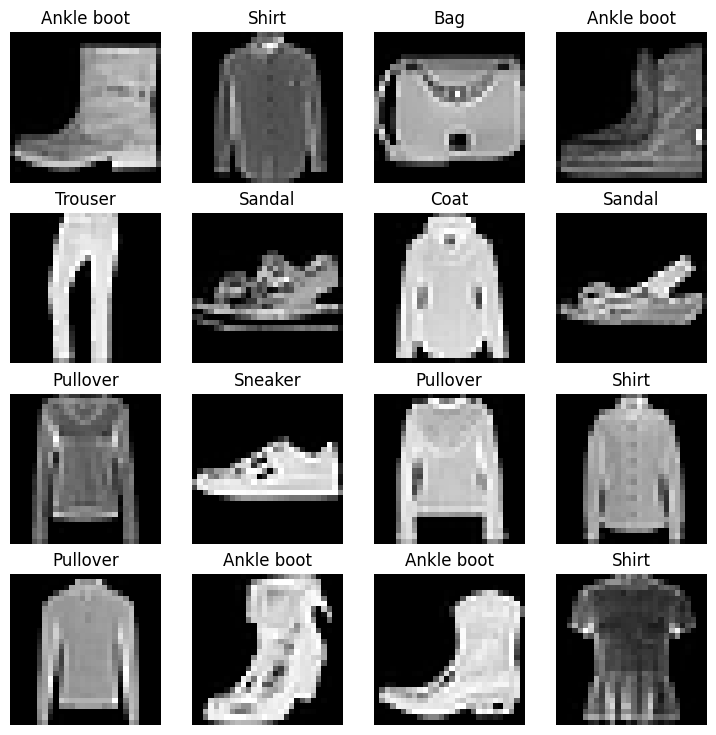

In [92]:
torch.manual_seed(42)
fig = plt.figure(figsize=(9,9))
rows,cols = 4,4
for i in range(1,rows*cols+1):
    rand_ind = torch.randint(0,len(train_data),size=[1]).item()
    print(rand_ind)
    image,labels = train_data[rand_ind]
    fig.add_subplot(rows,cols,i)
    plt.imshow(image.squeeze(),cmap="gray")
    plt.title(class_name[labels])
    plt.axis(False)


## dataloader and minibatches

torch.Size([1, 28, 28])


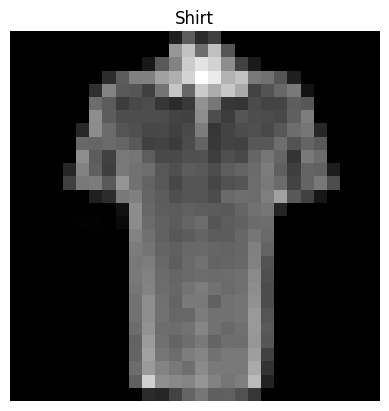

In [93]:
from torch.utils.data import DataLoader
BATCH_SIZE = 32
train_data_loader = DataLoader(dataset = train_data,
                               batch_size = BATCH_SIZE,
                               shuffle = True)

test_data_loader = DataLoader(dataset = test_data,
                              batch_size = BATCH_SIZE,
                              shuffle =False)

print(train_data_loader)
print(test_data_loader)
train_feat,train_label = next(iter(train_data_loader))
torch.manual_seed(42)
ran_ind = torch.randint(0,len(train_feat),size=[1]).item()
image1,label1 =  train_feat[ran_ind],train_label[ran_ind]
plt.imshow(image1.squeeze(),cmap="gray")
plt.title(class_name[label1])
plt.axis(False)
print(image1.shape)

## model

In [94]:
class fashionMNISTmodel(nn.Module):
    def __init__(self,
                 input_size:int,
                 hidden_units:int,
                 output_size:int):
        super().__init__()
        self.layer_stack = nn.Sequential(
            nn.Flatten(),
            nn.Linear(in_features=input_size,out_features=hidden_units),
            nn.Linear(in_features=hidden_units,out_features=output_size)
        )

    def forward(self,x):
        return self.layer_stack(x)

In [95]:
torch.manual_seed(42)
model = fashionMNISTmodel(input_size=784,
                          hidden_units=10,
                          output_size=len(class_name))

print(model)

fashionMNISTmodel(
  (layer_stack): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=10, bias=True)
    (2): Linear(in_features=10, out_features=10, bias=True)
  )
)


In [96]:
dummy_x = torch.rand([1,1,28,28])
print(model(dummy_x))
print(model.state_dict())

tensor([[-0.0315,  0.3171,  0.0531, -0.2525,  0.5959,  0.2112,  0.3233,  0.2694,
         -0.1004,  0.0157]], grad_fn=<AddmmBackward0>)
OrderedDict({'layer_stack.1.weight': tensor([[ 0.0273,  0.0296, -0.0084,  ..., -0.0142,  0.0093,  0.0135],
        [-0.0188, -0.0354,  0.0187,  ..., -0.0106, -0.0001,  0.0115],
        [-0.0008,  0.0017,  0.0045,  ..., -0.0127, -0.0188,  0.0059],
        ...,
        [-0.0116,  0.0273, -0.0344,  ...,  0.0176,  0.0283, -0.0011],
        [-0.0230,  0.0257,  0.0291,  ..., -0.0187, -0.0087,  0.0001],
        [ 0.0176, -0.0147,  0.0053,  ..., -0.0336, -0.0221,  0.0205]]), 'layer_stack.1.bias': tensor([-0.0093,  0.0283, -0.0033,  0.0255,  0.0017,  0.0037, -0.0302, -0.0123,
         0.0018,  0.0163]), 'layer_stack.2.weight': tensor([[ 0.0614, -0.0687,  0.0021,  0.2718,  0.2109,  0.1079, -0.2279, -0.1063,
          0.2019,  0.2847],
        [-0.1495,  0.1344, -0.0740,  0.2006, -0.0475, -0.2514, -0.3130, -0.0118,
          0.0932, -0.1864],
        [ 0.2488,  0

## loss function and optimizer

In [97]:
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(params=model.parameters(),lr=0.1)

## tracking model performance and speed

In [98]:
from timeit import default_timer as timer

def print_train_time(start:float,
                     end:float,
                     device:torch.device=None):
    total_time= end - start
    print(f"total time:{total_time:.3f},device name :{device}")
    return total_time

In [99]:
start =timer()
print("hi")
end =timer()
print(print_train_time(start=start,end=end,device="cpu"))

hi
total time:0.000,device name :cpu
0.00016945800052781124


## create training loop and train model on batches

In [100]:
from tqdm.auto import tqdm

def accuracy_func(y_true, y_pred):
    correct = torch.eq(y_true, y_pred.argmax(dim=1)).sum().item()
    acc = (correct / len(y_true)) * 100
    return acc

torch.manual_seed(42)
train_start = timer()

epochs = 3
for epoch in tqdm(range(epochs)):
    print(f"epoch:{epoch}\n----")
    train_loss = 0
    train_acc = 0

    for batch, (x, y) in enumerate(train_data_loader):
        model.train()
        y_pred = model(x)
        loss = loss_fn(y_pred, y)
        train_loss += loss
        train_acc += accuracy_func(y, y_pred)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        if batch % 400 == 0:
            print(f"looked at {batch * len(x)}/{len(train_data_loader.dataset)}")

    train_loss /= len(train_data_loader)
    train_acc /= len(train_data_loader)

    test_loss, test_acc = 0, 0
    model.eval()
    with torch.inference_mode():
        for x_test, y_test in test_data_loader:
            test_pred = model(x_test)
            test_loss += loss_fn(test_pred, y_test)
            test_acc += accuracy_func(y_test, test_pred)

        test_loss /= len(test_data_loader)
        test_acc /= len(test_data_loader)

    print(f"train_loss: {train_loss:.4f} | train_acc: {train_acc:.2f}%")
    print(f"test_loss: {test_loss:.4f} | test_acc: {test_acc:.2f}%")
end_train= timer()
train_model_time = print_train_time(start=train_start,end=end_train,device=str(next(model.parameters()).device))

  0%|          | 0/3 [00:00<?, ?it/s]

epoch:0
----
looked at 0/60000
looked at 12800/60000
looked at 25600/60000
looked at 38400/60000
looked at 51200/60000
train_loss: 0.5904 | train_acc: 79.17%
test_loss: 0.5095 | test_acc: 82.04%
epoch:1
----
looked at 0/60000
looked at 12800/60000
looked at 25600/60000
looked at 38400/60000
looked at 51200/60000
train_loss: 0.4763 | train_acc: 83.32%
test_loss: 0.4799 | test_acc: 83.20%
epoch:2
----
looked at 0/60000
looked at 12800/60000
looked at 25600/60000
looked at 38400/60000
looked at 51200/60000
train_loss: 0.4550 | train_acc: 84.05%
test_loss: 0.4766 | test_acc: 83.43%
total time:28.976,device name :cpu


In [102]:
torch.manual_seed(42)
def eval_model(model:torch.nn.Module,
               data_loader:torch.utils.data.DataLoader,
               loss_fn:torch.nn.Module,
               accuracy_func,
               device:torch.device):
    loss,acc =0,0
    model.eval()
    with torch.inference_mode():
        for x,y in data_loader:
            x1,y1 = x.to(device),y.to(device)
            y_pred1 = model(x1)
            loss+=loss_fn(y_pred1,y1)
            acc+= accuracy_func(y1, y_pred1)

        loss/= len(data_loader)
        acc/=len(data_loader)

    return {"model_name":model.__class__.__name__,
            "model_loss":loss.item(),
            "model_acc":acc}      

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

model_results = eval_model(model=model,
                           data_loader=test_data_loader,
                           loss_fn=loss_fn,
                           accuracy_func=accuracy_func,
                           device=device)

print(model_results)

{'model_name': 'fashionMNISTmodel', 'model_loss': 0.47663894295692444, 'model_acc': 83.42651757188499}


In [116]:
class fashionMNISTmodel1(nn.Module):
    def __init__(self,
                 input_size:int,
                 hidden_units:int,
                 output_size:int):
        super().__init__()
        self.layer_stack = nn.Sequential(
            nn.Flatten(),
            nn.Linear(in_features=input_size,out_features=hidden_units),
            nn.LeakyReLU(),
            nn.Linear(in_features=hidden_units,out_features=output_size),
            nn.LeakyReLU()
        )

    def forward(self,x):
        return self.layer_stack(x)

In [117]:
torch.manual_seed(42)
model1 = fashionMNISTmodel1(input_size=784,
                          hidden_units=10,
                          output_size=len(class_name)).to(device=device)

print(next(model.parameters()).device)

cuda:0


## loss func and optimizer


In [118]:
loss_fn1 = nn.CrossEntropyLoss()
optimizer1 = torch.optim.SGD(params=model1.parameters(),
                             lr=0.1)

In [119]:
def train_step(model1:torch.nn.Module,
               data_loader:torch.utils.data.DataLoader,
               loss_func:torch.nn.Module,
               optimizer:torch.optim.Optimizer,
               accuracy_fn,
               device:torch.device = device):


    train_loss1 = 0
    train_acc1 = 0
    model1.train()

    for batch1, (x, y) in enumerate(data_loader):
        x2,y2 = x.to(device),y.to(device)
        y_pred2 = model(x2)
        loss = loss_func(y_pred2, y2)
        train_loss1 += loss
        train_acc1 += accuracy_fn(y2, y_pred2)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        
    train_loss1 /= len(data_loader)
    train_acc1 /= len(data_loader)
    print(f"train_loss: {train_loss1:.4f} | train_acc: {train_acc1:.2f}%")

In [120]:
def test_step(model1:torch.nn.Module,
               data_loader:torch.utils.data.DataLoader,
               loss_func:torch.nn.Module,
               accuracy_fn,
               device:torch.device = device):

    test_loss1, test_acc1 = 0, 0
    model1.eval()
    with torch.inference_mode():
        for x_test1, y_test1 in data_loader:
            x_test1, y_test1=x_test1.to(device), y_test1.to(device)
            test_pred1 = model(x_test1)
            test_loss1 += loss_func(test_pred1, y_test1)
            test_acc1 += accuracy_fn(y_test1, test_pred1)

        test_loss1 /= len(data_loader)
        test_acc1 /= len(data_loader)

    print(f"test_loss: {test_loss1:.4f} | test_acc: {test_acc1:.2f}%")


In [121]:
torch.manual_seed(42)
from timeit import default_timer as timer
train_start_time = timer()
epochs =3
for epoch in tqdm(range(epochs)):
    print(f"epoch:{epoch}\n----")
    train_step(model1 = model1,
               data_loader=train_data_loader,
               loss_func=loss_fn1,
               optimizer=optimizer1,
               accuracy_fn=accuracy_func,
               device=device)

    test_step(model1=model1,
              data_loader=test_data_loader,
              loss_func=loss_fn1,
              accuracy_fn=accuracy_func,
              device=device)
    
end_train_time = timer()
total_time = print_train_time(start=train_start_time,end=end_train_time,
                              device=device)   

  0%|          | 0/3 [00:00<?, ?it/s]

epoch:0
----
train_loss: 0.4303 | train_acc: 84.94%
test_loss: 0.4766 | test_acc: 83.43%
epoch:1
----
train_loss: 0.4303 | train_acc: 84.94%
test_loss: 0.4766 | test_acc: 83.43%
epoch:2
----
train_loss: 0.4303 | train_acc: 84.94%
test_loss: 0.4766 | test_acc: 83.43%
total time:30.160,device name :cuda


In [ ]:
torch.manual_seed(42)
def eval_model(model:torch.nn.Module,
               data_loader:torch.utils.data.DataLoader,
               loss_fn:torch.nn.Module,
               accuracy_func,
               device:torch.device):
    loss1,acc1 =0,0
    model.eval()
    with torch.inference_mode():
        for x,y in data_loader:
            xa,ya = x.to(device),y.to(device)
            y_preda = model(xa)
            loss1+=loss_fn(y_preda,ya)
            acc1+= accuracy_func(ya, y_preda)

        loss1/= len(data_loader)
        acc1/=len(data_loader)

    return {"model_name":model.__class__.__name__,
            "model_loss":loss1.item(),
            "model_acc":acc1}      

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model1.to(device)

model_results = eval_model(model=model,
                           data_loader=test_data_loader,
                           loss_fn=loss_fn,
                           accuracy_func=accuracy_func,
                           device=device)

print(model_results)

{'model_name': 'fashionMNISTmodel', 'model_loss': 0.47663894295692444, 'model_acc': 83.42651757188499}
